# Lesson 18 — Statistical Analysis and Paper Figures

Visual comparison alone is not enough for a research paper. We need:
- **Confidence intervals** — how much does performance vary across random seeds?
- **Significance tests** — are the observed differences real or just noise?
- **Effect sizes** — how large are the differences in practice?
- **Publication-quality figures** — clean, readable, B&W-safe

This lesson applies these tools to the results from Lessons 13–17 and produces the figures and table that will appear in the research paper.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.stats import norm as sp_norm, wilcoxon as wilcoxon_test, friedmanchisquare
from scipy.optimize import minimize as sp_minimize
from scipy.stats.qmc import LatinHypercube
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from sklearn.ensemble import RandomForestRegressor
from scipy.interpolate import RBFInterpolator
import cocoex

warnings.filterwarnings('ignore')

RANDOM_SEED   = 42
N_SEEDS       = 5
N_SEEDS_BBOB  = 3
N_INIT        = 10
N_INIT_2D     = 15
N_ITER        = 15
EPOCHS_BO     = 100
N_MEMBERS     = 5
T_DROPOUT     = 50
SCR_MAX       = 0.20
N_BOOT        = 500

FORRESTER_OPT = -6.020740
BRANIN_OPT    =  0.397887
FUNC_IDS      = [1, 8, 15]
FUNC_SHORT    = ['Sphere', 'Rosenbrock', 'Rastrigin']
INSTANCE      = 1
DIM_BBOB      = 2

SURROGATES   = ['gp', 'mc_dropout', 'deep_ensemble', 'rbf', 'rf']
LABELS       = ['GP', 'MC Dropout', 'Deep Ensemble', 'RBF', 'Random Forest']
COLORS       = ['steelblue', 'seagreen', 'darkorange', 'tomato', 'purple']
PAPER_STYLES = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]

## Benchmark functions and BBOB wrapper

In [2]:
def forrester(x):
    x = float(np.asarray(x).ravel()[0])
    return (6*x - 2)**2 * np.sin(12*x - 4)


def branin(x):
    x  = np.asarray(x).ravel()
    x1 = x[0] * 15 - 5
    x2 = x[1] * 15
    return float((x2 - 5.1/(4*np.pi**2)*x1**2 + 5/np.pi*x1 - 6)**2
                 + 10*(1 - 1/(8*np.pi))*np.cos(x1) + 10)


def make_bbob(func_id, dim, instance=INSTANCE):
    suite = cocoex.Suite('bbob', f'instances:{instance}',
                         f'dimensions:{dim} function_indices:{func_id}')
    f  = suite[0]
    lb = f.lower_bounds.copy()
    ub = f.upper_bounds.copy()
    def wrapped(x):
        return float(f(lb + np.asarray(x).ravel() * (ub - lb)))
    wrapped._alive = (suite, f)
    return wrapped


def find_fopt(func, dim, n_restarts=20):
    rng  = np.random.RandomState(RANDOM_SEED)
    best = np.inf
    for _ in range(n_restarts):
        res = sp_minimize(func, rng.rand(dim), method='L-BFGS-B',
                          bounds=[(1e-6, 1-1e-6)]*dim,
                          options={'maxiter': 10000, 'ftol': 1e-15})
        best = min(best, res.fun)
    return best

## Neural network and surrogate implementations

In [3]:
class Net(nn.Module):
    def __init__(self, d_in, p=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 64), nn.ReLU(), nn.Dropout(p),
            nn.Linear(64, 64),   nn.ReLU(), nn.Dropout(p),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_net(X, y, epochs, seed):
    torch.manual_seed(seed)
    model = Net(X.shape[1])
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
    Xt    = torch.tensor(X, dtype=torch.float32)
    yt    = torch.tensor(y, dtype=torch.float32)
    model.train()
    for _ in range(epochs):
        opt.zero_grad()
        nn.MSELoss()(model(Xt), yt).backward()
        opt.step()
    return model


def surrogate_predict(stype, X_tr, y_tr, X_cand, seed=0, epochs=100):
    torch.manual_seed(seed)

    if stype == 'gp':
        kernel = Matern(nu=2.5, length_scale_bounds=(1e-3, 10.0))
        gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-4,
                                        n_restarts_optimizer=2,
                                        normalize_y=True, random_state=seed)
        gpr.fit(X_tr, y_tr)
        mu, std = gpr.predict(X_cand, return_std=True)
        return mu, np.maximum(std, 1e-8)

    if stype == 'mc_dropout':
        model = train_net(X_tr, y_tr, epochs, seed)
        model.train()
        Xc = torch.tensor(X_cand, dtype=torch.float32)
        with torch.no_grad():
            preds = np.stack([model(Xc).numpy() for _ in range(T_DROPOUT)])
        return preds.mean(0), np.maximum(preds.std(0), 1e-8)

    if stype == 'deep_ensemble':
        preds = []
        for i in range(N_MEMBERS):
            m  = train_net(X_tr, y_tr, epochs, seed + i * 17)
            m.eval()
            Xc = torch.tensor(X_cand, dtype=torch.float32)
            with torch.no_grad():
                preds.append(m(Xc).numpy())
        preds = np.stack(preds)
        return preds.mean(0), np.maximum(preds.std(0), 1e-8)

    if stype == 'rbf':
        rbf = RBFInterpolator(X_tr, y_tr, kernel='thin_plate_spline', smoothing=1e-3)
        mu  = rbf(X_cand)
        diffs = X_cand[:, None, :] - X_tr[None, :, :]
        min_d = np.linalg.norm(diffs, axis=-1).min(axis=1)
        return mu, min_d / (min_d.max() + 1e-8) + 0.05

    if stype == 'rf':
        rf = RandomForestRegressor(n_estimators=100, random_state=seed)
        rf.fit(X_tr, y_tr)
        preds = np.stack([t.predict(X_cand) for t in rf.estimators_])
        return preds.mean(0), np.maximum(preds.std(0), 1e-8)

    raise ValueError(f'Unknown surrogate: {stype}')

## BO loop and statistical helpers

Key new functions:
- `bootstrap_ci(runs)` — resample seeds 500 times to get the 95% CI on the median curve
- `pairwise_wilcoxon(results)` — Wilcoxon signed-rank test for every pair of surrogates
- `final_gaps(hists)` — extract the final gap from each seed's history

In [4]:
def ei(mu, std, best, xi=0.01):
    imp = best - mu - xi
    z   = imp / (std + 1e-8)
    return imp * sp_norm.cdf(z) + std * sp_norm.pdf(z)


def run_bo(stype, func, dim, seed, f_opt,
           n_init, n_iter, epochs=EPOCHS_BO, scr_max=SCR_MAX):
    rng = np.random.RandomState(seed)
    sampler = LatinHypercube(d=dim, seed=seed)
    X_obs   = sampler.random(n_init)
    y_obs   = np.array([func(x) for x in X_obs])

    true_calls = n_init
    surr_calls = 0
    best_true  = y_obs.min()
    history    = [(true_calls, max(best_true - f_opt, 0.0))]

    for _ in range(n_iter):
        y_mean = y_obs.mean()
        y_sc   = y_obs.std() + 1e-8
        y_std  = (y_obs - y_mean) / y_sc

        X_cand      = rng.rand(200, dim)
        mu_s, sig_s = surrogate_predict(stype, X_obs, y_std, X_cand, seed, epochs)
        mu          = mu_s * y_sc + y_mean
        sig         = sig_s * y_sc

        acq             = ei(mu, sig, best_true)
        idx             = np.argmax(acq)
        x_next, mu_next = X_cand[idx], mu[idx]

        proj     = (surr_calls + 1) / (true_calls + surr_calls + 1)
        use_surr = (scr_max > 0) and (proj <= scr_max)

        if use_surr:
            y_next = mu_next
            surr_calls += 1
        else:
            y_next = func(x_next)
            true_calls += 1
            best_true = min(best_true, y_next)

        X_obs = np.vstack([X_obs, x_next])
        y_obs = np.append(y_obs, y_next)
        history.append((true_calls, max(best_true - f_opt, 0.0)))

    return history


def run_seeds(stype, func, dim, f_opt, n_init, n_iter, n_seeds, epochs=EPOCHS_BO):
    return [run_bo(stype, func, dim, RANDOM_SEED + s, f_opt,
                   n_init=n_init, n_iter=n_iter, epochs=epochs)
            for s in range(n_seeds)]


def to_grid(hists, n_init):
    max_tc = max(h[-1][0] for h in hists)
    grid   = np.arange(n_init, max_tc + 1)
    runs   = np.array([np.interp(grid, [h[0] for h in hist], [h[1] for h in hist])
                       for hist in hists])
    return grid, runs


def bootstrap_ci(runs, n_boot=N_BOOT, ci=0.95):
    rng  = np.random.RandomState(RANDOM_SEED)
    n    = runs.shape[0]
    boot = np.array([np.median(runs[rng.randint(0, n, n)], axis=0)
                     for _ in range(n_boot)])
    alpha = (1 - ci) / 2
    return (np.percentile(boot, alpha*100, axis=0),
            np.percentile(boot, (1-alpha)*100, axis=0))


def final_gaps(hists):
    return np.array([h[-1][1] for h in hists])


def pairwise_wilcoxon(results):
    n = len(SURROGATES)
    p_mat = np.ones((n, n))
    for i, si in enumerate(SURROGATES):
        for j, sj in enumerate(SURROGATES):
            if i == j:
                continue
            try:
                _, p = wilcoxon_test(final_gaps(results[si]), final_gaps(results[sj]))
            except ValueError:
                p = 1.0
            p_mat[i, j] = p
    return p_mat

## Run all experiments

This cell runs everything and caches results. Subsequent cells just plot from the cache.

In [5]:
print(f'Running Forrester 1D ({N_SEEDS} seeds)...')
forr_results = {}
for stype, label in zip(SURROGATES, LABELS):
    print(f'  {label}...')
    forr_results[stype] = run_seeds(stype, forrester, 1, FORRESTER_OPT,
                                     N_INIT, N_ITER, N_SEEDS)

print(f'Running Branin 2D ({N_SEEDS} seeds)...')
bran_results = {}
for stype, label in zip(SURROGATES, LABELS):
    print(f'  {label}...')
    bran_results[stype] = run_seeds(stype, branin, 2, BRANIN_OPT,
                                     N_INIT_2D, N_ITER, N_SEEDS)

print(f'Running BBOB ({N_SEEDS_BBOB} seeds)...')
f_opts = {fid: find_fopt(make_bbob(fid, DIM_BBOB), DIM_BBOB) for fid in FUNC_IDS}
bbob_results = {}
for fid, fname in zip(FUNC_IDS, FUNC_SHORT):
    bbob_results[fid] = {}
    func = make_bbob(fid, DIM_BBOB)
    for stype, label in zip(SURROGATES, LABELS):
        print(f'  {fname} × {label}...')
        bbob_results[fid][stype] = run_seeds(stype, func, DIM_BBOB,
                                              f_opts[fid], N_INIT, N_ITER, N_SEEDS_BBOB)
print('Done.')

Running Forrester 1D (5 seeds)...
  GP...
  MC Dropout...
  Deep Ensemble...
  RBF...
  Random Forest...
Running Branin 2D (5 seeds)...
  GP...
  MC Dropout...
  Deep Ensemble...
  RBF...
  Random Forest...
Running BBOB (3 seeds)...
  Sphere × GP...
  Sphere × MC Dropout...
  Sphere × Deep Ensemble...
  Sphere × RBF...
  Sphere × Random Forest...
  Rosenbrock × GP...
  Rosenbrock × MC Dropout...
  Rosenbrock × Deep Ensemble...
  Rosenbrock × RBF...
  Rosenbrock × Random Forest...
  Rastrigin × GP...
  Rastrigin × MC Dropout...
  Rastrigin × Deep Ensemble...
  Rastrigin × RBF...
  Rastrigin × Random Forest...
Done.


---
## Part 1 — Bootstrap convergence curves (Forrester 1D)

The shaded band is the **95% bootstrap confidence interval** on the median convergence curve. It is computed by resampling seeds with replacement 500 times.

**Reading the plot:** if the CI bands of two surrogates overlap at a given budget, the difference at that point is not statistically reliable with N=5 seeds.

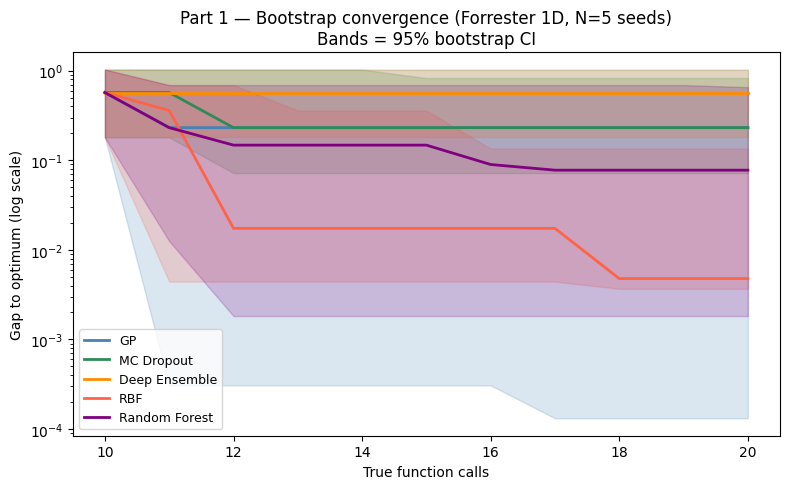

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for stype, label, color in zip(SURROGATES, LABELS, COLORS):
    grid, runs = to_grid(forr_results[stype], N_INIT)
    med        = np.median(runs, axis=0)
    lo, hi     = bootstrap_ci(runs)
    ax.semilogy(grid, np.maximum(med, 1e-6), color=color, label=label, lw=2)
    ax.fill_between(grid, np.maximum(lo, 1e-6), np.maximum(hi, 1e-6),
                    alpha=0.2, color=color)
ax.set_xlabel('True function calls')
ax.set_ylabel('Gap to optimum (log scale)')
ax.set_title(f'Part 1 — Bootstrap convergence (Forrester 1D, N={N_SEEDS} seeds)\n'
             f'Bands = 95% bootstrap CI')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## Part 2 — Final gap distribution (box plots)

Box plots reveal the **spread** of final gaps across seeds — something the convergence curve hides behind a single median line.

A tall box = high variance = unreliable surrogate. A short box = consistent. Outliers (circles beyond whiskers) = occasional failures.

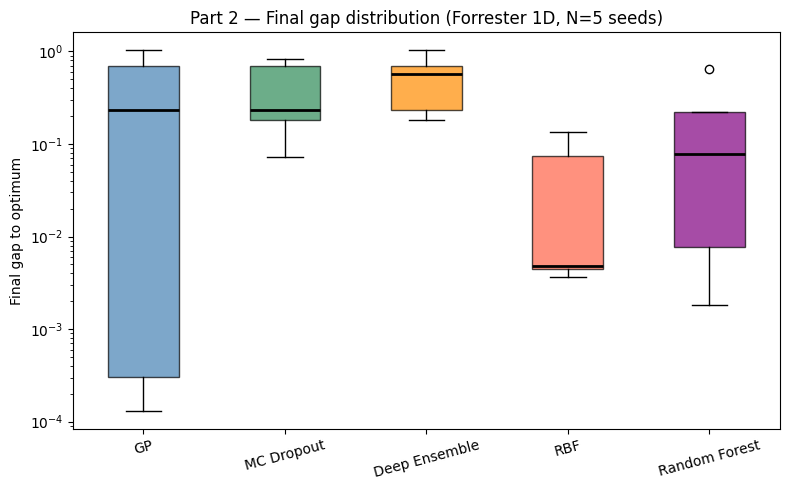

In [7]:
data = [final_gaps(forr_results[s]) for s in SURROGATES]

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(data, patch_artist=True, notch=False,
                medianprops=dict(color='black', lw=2))
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticks(range(1, len(LABELS) + 1))
ax.set_xticklabels(LABELS, rotation=15)
ax.set_ylabel('Final gap to optimum')
ax.set_title(f'Part 2 — Final gap distribution (Forrester 1D, N={N_SEEDS} seeds)')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

---
## Part 3 — Wilcoxon pairwise significance

The **Wilcoxon signed-rank test** is a non-parametric paired test. Each cell (row i, col j) shows the p-value for "surrogate i beats surrogate j" across matched seeds.

- ✓ = p < 0.05 (significant at 5% level)
- Otherwise the p-value is shown
- Darker blue = more significant

With N=5 seeds, most comparisons will NOT be significant — this is expected and teaches the importance of running enough seeds.

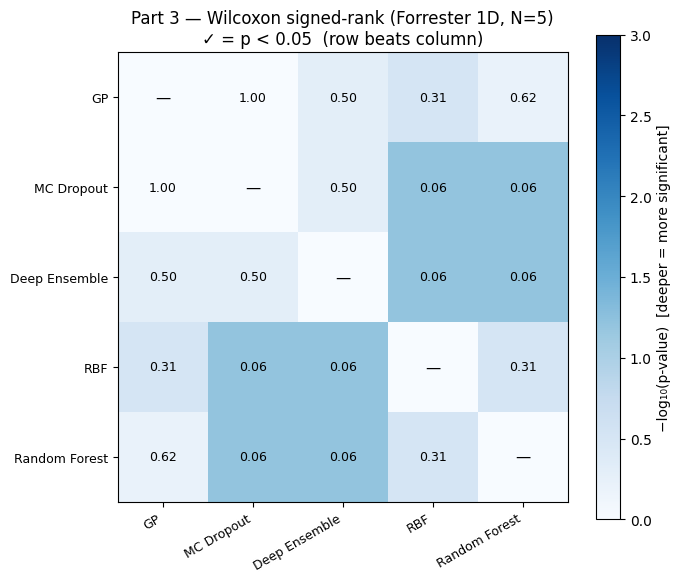

Significant pairs (p < 0.05): 0 out of 20
Tip: re-run with N_SEEDS=10 to see more significant differences.


In [8]:
p_mat = pairwise_wilcoxon(forr_results)
sig   = p_mat < 0.05

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(-np.log10(p_mat + 1e-10), cmap='Blues', vmin=0, vmax=3)
plt.colorbar(im, ax=ax, label='−log₁₀(p-value)  [deeper = more significant]')
ax.set_xticks(range(len(SURROGATES)))
ax.set_xticklabels(LABELS, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(SURROGATES)))
ax.set_yticklabels(LABELS, fontsize=9)
for i in range(len(SURROGATES)):
    for j in range(len(SURROGATES)):
        if i == j:
            ax.text(j, i, '—', ha='center', va='center', fontsize=11)
        else:
            mark = '✓' if sig[i, j] else f'{p_mat[i,j]:.2f}'
            ax.text(j, i, mark, ha='center', va='center', fontsize=9,
                    color='white' if -np.log10(p_mat[i,j]+1e-10) > 1.5 else 'black')
ax.set_title(f'Part 3 — Wilcoxon signed-rank (Forrester 1D, N={N_SEEDS})\n'
             f'✓ = p < 0.05  (row beats column)')
plt.tight_layout()
plt.show()

n_sig = sig.sum() - np.trace(sig)
print(f'Significant pairs (p < 0.05): {n_sig} out of {len(SURROGATES)**2 - len(SURROGATES)}')
print('Tip: re-run with N_SEEDS=10 to see more significant differences.')

---
## Part 4 — BBOB multi-function bars with error bars and Friedman test

Bar height = median final gap. Error bars = IQR (interquartile range).

The **Friedman test** is the non-parametric equivalent of repeated-measures ANOVA. It answers: "across all seeds, is there a statistically significant difference between surrogates?" p < 0.05 means at least one surrogate is different.

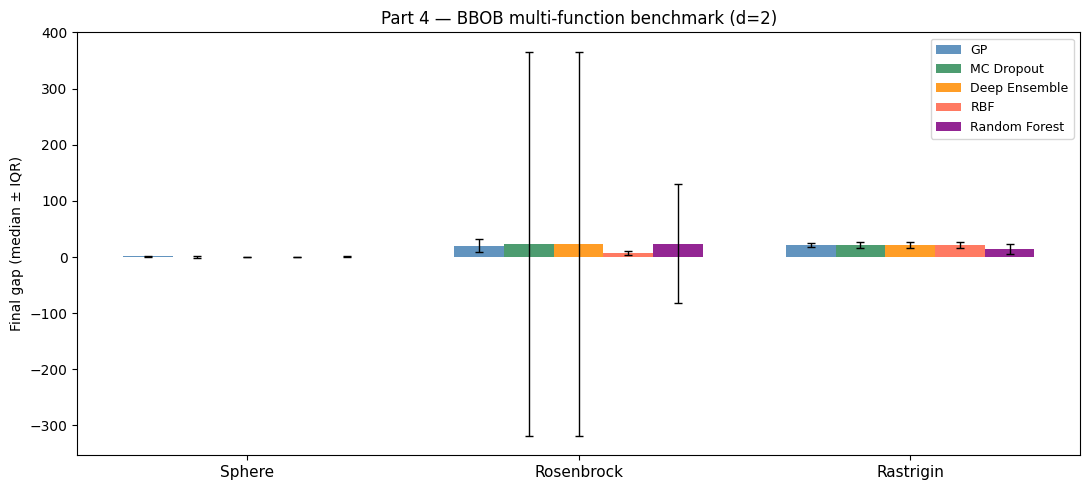

Friedman test per function:
  Sphere: χ²=1.52, p=0.8236
  Rosenbrock: χ²=7.66, p=0.1050
  Rastrigin: χ²=2.38, p=0.6657


In [9]:
n_sur = len(SURROGATES)
n_fun = len(FUNC_IDS)
x     = np.arange(n_fun)
width = 0.75 / n_sur

fig, ax = plt.subplots(figsize=(11, 5))
for i, (stype, label, color) in enumerate(zip(SURROGATES, LABELS, COLORS)):
    meds, iqrs = [], []
    for fid in FUNC_IDS:
        gaps = final_gaps(bbob_results[fid][stype])
        meds.append(np.median(gaps))
        iqrs.append(np.percentile(gaps, 75) - np.percentile(gaps, 25))
    offset = (i - n_sur/2 + 0.5) * width
    ax.bar(x + offset, meds, width, label=label, color=color, alpha=0.85,
           yerr=iqrs, capsize=3, error_kw=dict(elinewidth=1))

ax.set_xticks(x)
ax.set_xticklabels(FUNC_SHORT, fontsize=11)
ax.set_ylabel('Final gap (median ± IQR)')
ax.set_title('Part 4 — BBOB multi-function benchmark (d=2)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Friedman test per function:')
for fid, fname in zip(FUNC_IDS, FUNC_SHORT):
    gaps_per = [final_gaps(bbob_results[fid][s]) for s in SURROGATES]
    min_len  = min(len(g) for g in gaps_per)
    gaps_per = [g[:min_len] for g in gaps_per]
    try:
        stat, p = friedmanchisquare(*gaps_per)
        sig_str = ' ← significant!' if p < 0.05 else ''
        print(f'  {fname}: χ²={stat:.2f}, p={p:.4f}{sig_str}')
    except Exception as e:
        print(f'  {fname}: test failed ({e})')

---
## Part 5 — Paper Figure 1: main convergence comparison

This is the figure that goes directly into the research paper.

Design choices for publication quality:
- Larger fonts (`fontsize=12`)
- Different line styles (`-`, `--`, `-.`, `:`) so it prints clearly in B&W
- 95% bootstrap CI as light shading (not distracting)
- `bbox_inches='tight'` for clean LaTeX embedding
- `dpi=150` for crisp printing

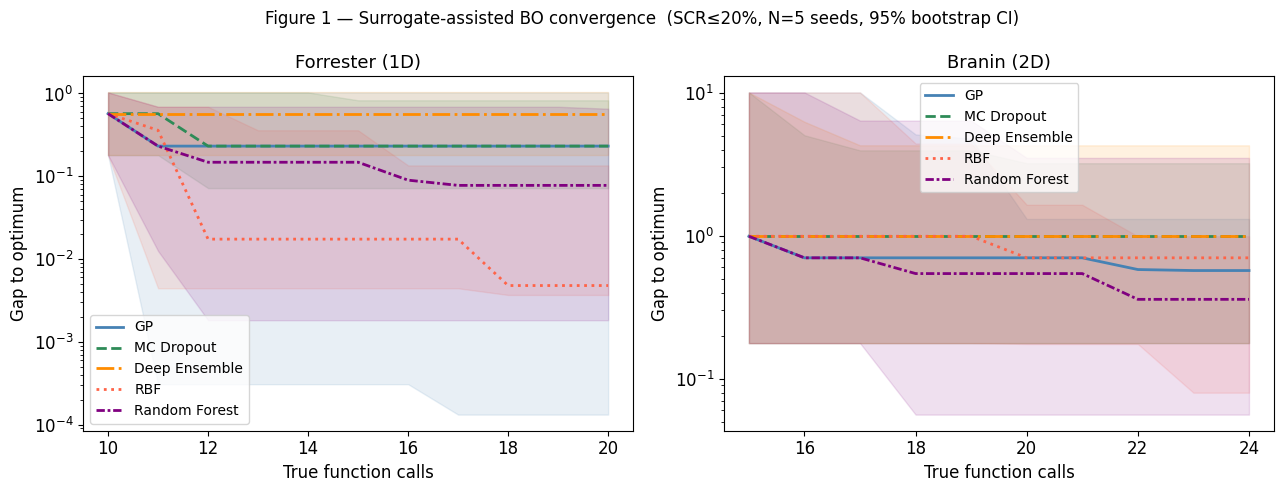

In [10]:
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 13,
                     'axes.labelsize': 12, 'legend.fontsize': 10})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, results, n_init, title in [
    (axes[0], forr_results, N_INIT,    'Forrester (1D)'),
    (axes[1], bran_results, N_INIT_2D, 'Branin (2D)'),
]:
    for stype, label, color, ls in zip(SURROGATES, LABELS, COLORS, PAPER_STYLES):
        grid, runs = to_grid(results[stype], n_init)
        med        = np.median(runs, axis=0)
        lo, hi     = bootstrap_ci(runs)
        ax.semilogy(grid, np.maximum(med, 1e-6),
                    color=color, ls=ls, label=label, lw=2)
        ax.fill_between(grid, np.maximum(lo, 1e-6), np.maximum(hi, 1e-6),
                        alpha=0.12, color=color)
    ax.set_xlabel('True function calls')
    ax.set_ylabel('Gap to optimum')
    ax.set_title(title)
    ax.legend()

fig.suptitle(
    f'Figure 1 — Surrogate-assisted BO convergence  '
    f'(SCR≤{int(SCR_MAX*100)}%, N={N_SEEDS} seeds, 95% bootstrap CI)',
    fontsize=12,
)
plt.tight_layout()
plt.show()

plt.rcParams.update(plt.rcParamsDefault)

---
## Part 6 — Results table

The main results table for the paper: median gap ± IQR, BBOB average rank, and win rate vs the GP baseline.

**Win rate** = fraction of seeds where this surrogate achieves a lower final gap than GP.

In [11]:
# BBOB ranks
ranks = np.zeros((len(SURROGATES), len(FUNC_IDS)))
for j, fid in enumerate(FUNC_IDS):
    gaps = [np.median(final_gaps(bbob_results[fid][s])) for s in SURROGATES]
    ranks[:, j] = np.argsort(np.argsort(gaps)) + 1
avg_ranks = ranks.mean(axis=1)

# Win rate vs GP
gp_gaps = final_gaps(forr_results['gp'])
win_rates = {s: np.mean(final_gaps(forr_results[s]) < gp_gaps) * 100
             for s in SURROGATES}

print(f"{'Surrogate':<18} {'Forr. gap':>16} {'Bran. gap':>16} {'BBOB rank':>10} {'Win vs GP':>10}")
print('-' * 75)
for stype, label in zip(SURROGATES, LABELS):
    fg  = final_gaps(forr_results[stype])
    bg  = final_gaps(bran_results[stype])
    idx = SURROGATES.index(stype)
    print(f"{label:<18} "
          f"{np.median(fg):>8.4f}±{(np.percentile(fg,75)-np.percentile(fg,25)):>6.4f} "
          f"{np.median(bg):>8.3f}±{(np.percentile(bg,75)-np.percentile(bg,25)):>6.3f} "
          f"{avg_ranks[idx]:>10.2f} "
          f"{win_rates[stype]:>9.0f}%")

print('\nLaTeX snippet:')
print('\\begin{tabular}{lrrrr}')
print('\\hline')
print('Surrogate & Forrester gap & Branin gap & BBOB rank & Win vs GP \\\\')
print('\\hline')
for stype, label in zip(SURROGATES, LABELS):
    fg  = final_gaps(forr_results[stype])
    bg  = final_gaps(bran_results[stype])
    idx = SURROGATES.index(stype)
    print(f"{label} & ${np.median(fg):.4f}$ & ${np.median(bg):.3f}$ "
          f"& ${avg_ranks[idx]:.1f}$ & ${win_rates[stype]:.0f}$\\% \\\\")
print('\\hline')
print('\\end{tabular}')

Surrogate                 Forr. gap        Bran. gap  BBOB rank  Win vs GP
---------------------------------------------------------------------------
GP                   0.2312±0.6905    0.571± 0.301       3.00         0%
MC Dropout           0.2312±0.5110    0.991± 1.888       3.00        20%
Deep Ensemble        0.5702±0.4596    0.991± 3.252       3.33         0%
RBF                  0.0048±0.0700    0.700± 0.604       2.33        60%
Random Forest        0.0775±0.2124    0.359± 1.305       3.33        60%

LaTeX snippet:
\begin{tabular}{lrrrr}
\hline
Surrogate & Forrester gap & Branin gap & BBOB rank & Win vs GP \\
\hline
GP & $0.2312$ & $0.571$ & $3.0$ & $0$\% \\
MC Dropout & $0.2312$ & $0.991$ & $3.0$ & $20$\% \\
Deep Ensemble & $0.5702$ & $0.991$ & $3.3$ & $0$\% \\
RBF & $0.0048$ & $0.700$ & $2.3$ & $60$\% \\
Random Forest & $0.0775$ & $0.359$ & $3.3$ & $60$\% \\
\hline
\end{tabular}


---
## Exercises

1. **Part 3** — Change `N_SEEDS = 10` and re-run Parts 1–3. How many more surrogate pairs become statistically significant (p < 0.05)?

2. **Part 1** — Do the 95% CI bands for GP and Deep Ensemble overlap at the last true call? If so, you cannot claim GP is significantly better based on this data alone.

3. **Part 5** — Replace `COLORS` with `['black']*5` and rely solely on `PAPER_STYLES` for differentiation. Is the figure still readable in grayscale?